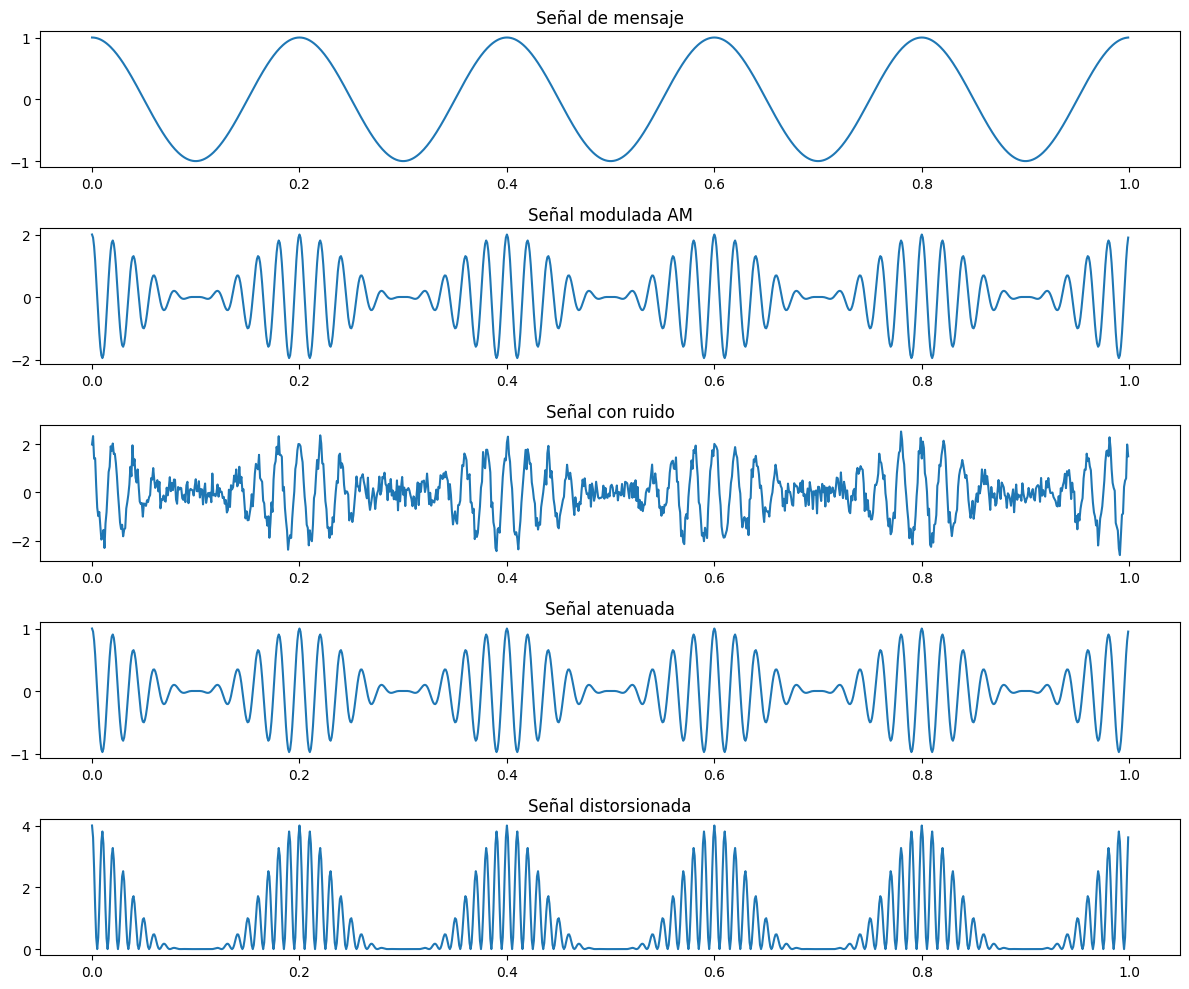

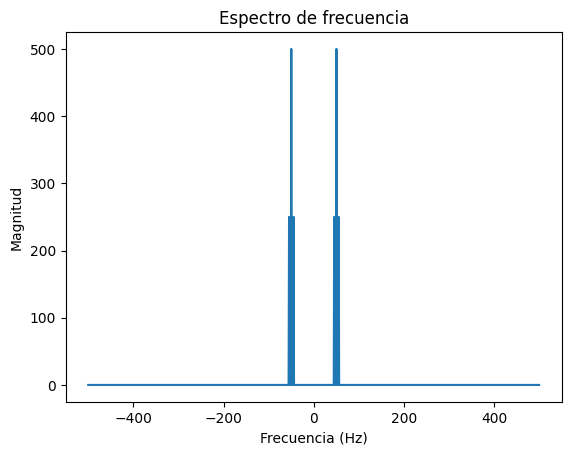

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARÁMETROS DEL SISTEMA
# =========================

fs = 1000  # frecuencia de muestreo (Hz)
t = np.arange(0, 1, 1/fs)  # vector de tiempo

# =========================
# SEÑAL DE MENSAJE
# =========================

fm = 5  # frecuencia del mensaje (Hz)
mensaje = np.cos(2 * np.pi * fm * t)

# =========================
# PORTADORA
# =========================

fc = 50  # frecuencia portadora (Hz)
portadora = np.cos(2 * np.pi * fc * t)

# =========================
# MODULACIÓN AM
# =========================

senal_modulada = (1 + mensaje) * portadora

# =========================
# FUNCIÓN FFT
# =========================

def calcular_fft(signal):
    return np.fft.fftshift(np.fft.fft(signal))

frecuencias = np.fft.fftshift(np.fft.fftfreq(len(t), 1/fs))

# =========================
# RUIDO
# =========================

ruido = np.random.normal(0, 0.3, len(t))
senal_ruido = senal_modulada + ruido

# =========================
# ATENUACIÓN
# =========================

senal_atenuada = 0.5 * senal_modulada

# =========================
# DISTORSIÓN (NO LINEAL)
# =========================

senal_distorsionada = senal_modulada**2

# =========================
# GRÁFICAS
# =========================

plt.figure(figsize=(12,10))

# 1. Señal original
plt.subplot(5,1,1)
plt.plot(t, mensaje)
plt.title("Señal de mensaje")

# 2. Señal modulada
plt.subplot(5,1,2)
plt.plot(t, senal_modulada)
plt.title("Señal modulada AM")

# 3. Ruido
plt.subplot(5,1,3)
plt.plot(t, senal_ruido)
plt.title("Señal con ruido")

# 4. Atenuación
plt.subplot(5,1,4)
plt.plot(t, senal_atenuada)
plt.title("Señal atenuada")

# 5. Distorsión
plt.subplot(5,1,5)
plt.plot(t, senal_distorsionada)
plt.title("Señal distorsionada")

plt.tight_layout()
plt.show()

# =========================
# ESPECTRO DE FRECUENCIA
# =========================

plt.plot(frecuencias, np.abs(calcular_fft(senal_modulada)))
plt.title("Espectro de frecuencia")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()